In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv(
    "../data/PSCompPars.csv",
    comment="#"
)

print(df.shape)

(6298, 320)


In [7]:
candidate_features = [
    "pl_rade",
    "pl_bmasse",
    "pl_dens",
    "pl_orbper",
    "pl_orbsmax",
    "pl_eqt",
    "st_mass",
    "st_rad",
    "st_teff"
]

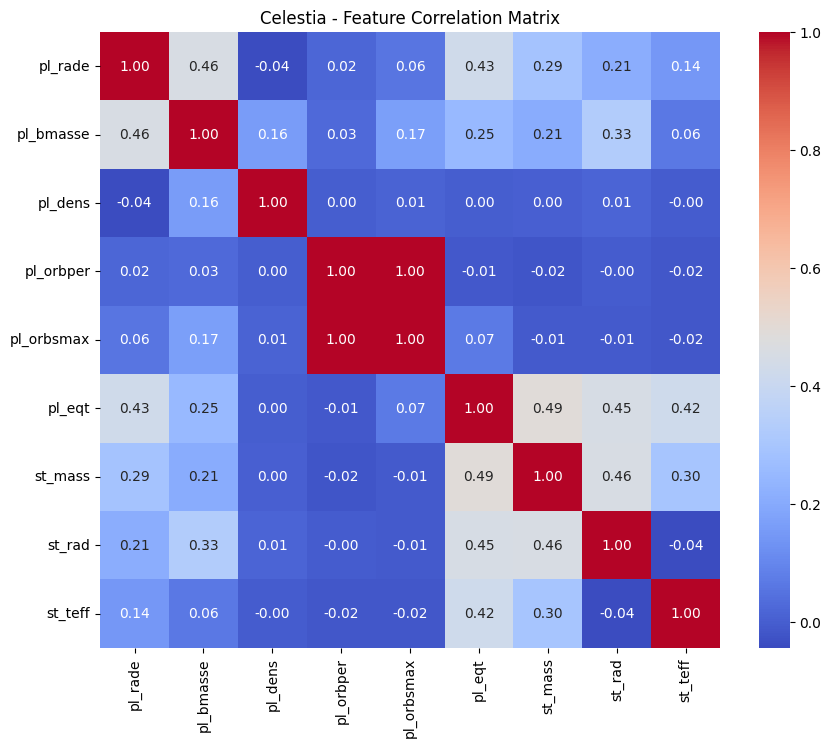

In [6]:
corr_matrix = df[candidate_features].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Celestia - Feature Correlation Matrix")
plt.show()

we remove pl_orbper due to multicolinearity

In [8]:
planet_features = [
    "pl_rade",
    "pl_bmasse",
    "pl_dens",
    "pl_orbsmax",
    "pl_eqt"
]

df[planet_features].dropna().shape

(4388, 5)

In [9]:
for col in planet_features:
    print(col, df[col].isnull().sum())

pl_rade 60
pl_bmasse 41
pl_dens 151
pl_orbsmax 435
pl_eqt 1613


In [12]:
planet_features_core = [
    "pl_rade",
    "pl_bmasse",
    "pl_dens",
    "pl_orbsmax"
]

df[planet_features_no_temp].dropna().shape

(5733, 4)

5733 - 4388 = 1345 planets so make a core dataset A withouth temp for now. we do not remove it permanently because temperature may become one of the most interesting variables when we compare planet-only vs planet+star clustering. based on out heatmap

In [13]:
df[planet_features_core].isnull().any(axis=1).sum()

np.int64(565)

Potential preprocessing strategies:

1. Drop rows with missing values
2. Median imputation

Both will be evaluated before final clustering.

### understanding outliners

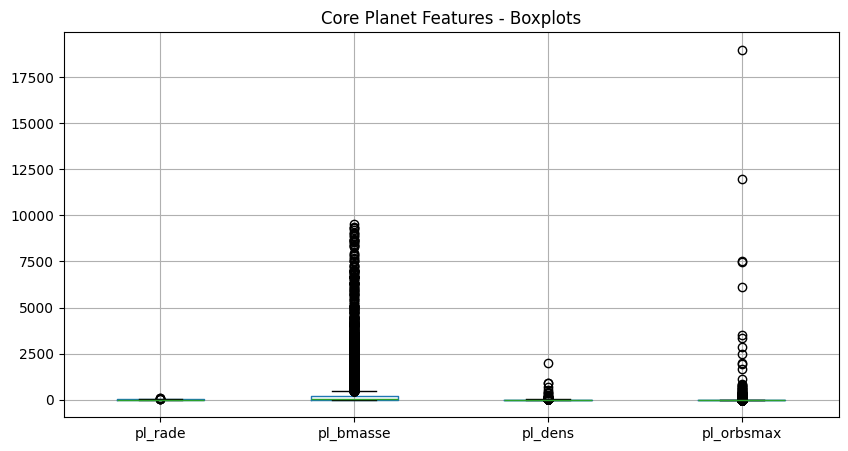

In [14]:
import matplotlib.pyplot as plt

planet_features_core = [
    "pl_rade",
    "pl_bmasse",
    "pl_dens",
    "pl_orbsmax"
]

df[planet_features_core].boxplot(
    figsize=(10, 5)
)

plt.title("Core Planet Features - Boxplots")
plt.show()

distributions span multiple orders of magnitude. so maybe log transformations?

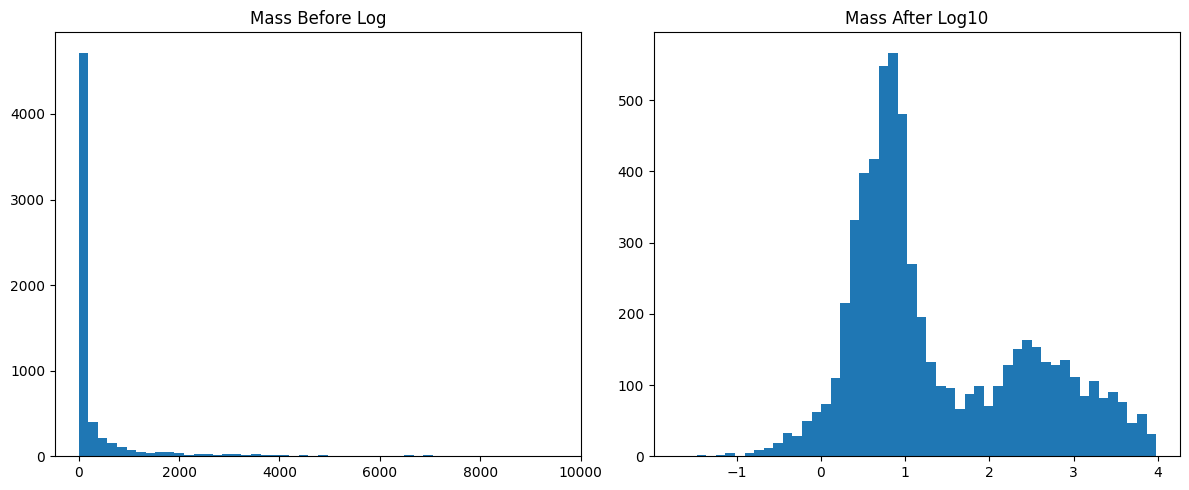

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(df["pl_bmasse"], bins=50)
axes[0].set_title("Mass Before Log")

axes[1].hist(np.log10(df["pl_bmasse"]), bins=50)
axes[1].set_title("Mass After Log10")

plt.tight_layout()
plt.show()

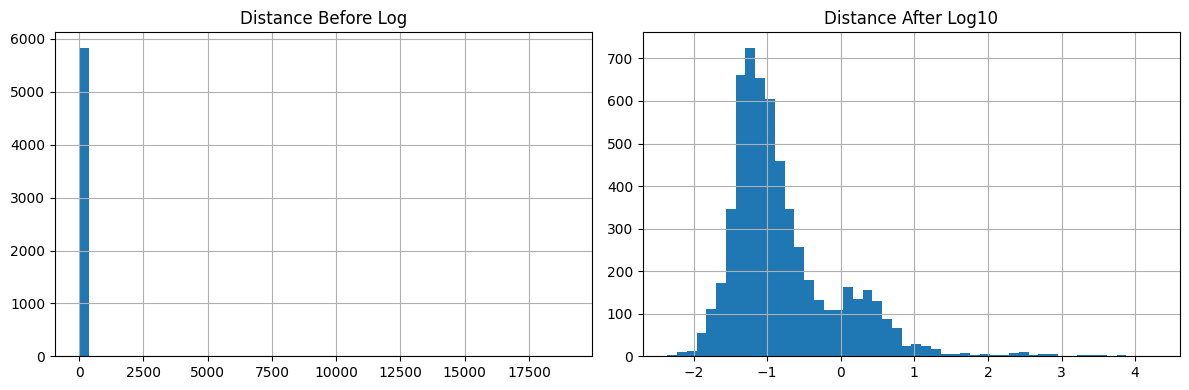

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

df["pl_orbsmax"].hist(bins=50, ax=ax[0])
ax[0].set_title("Distance Before Log")

np.log10(df["pl_orbsmax"]).hist(bins=50, ax=ax[1])
ax[1].set_title("Distance After Log10")

plt.tight_layout()
plt.show()

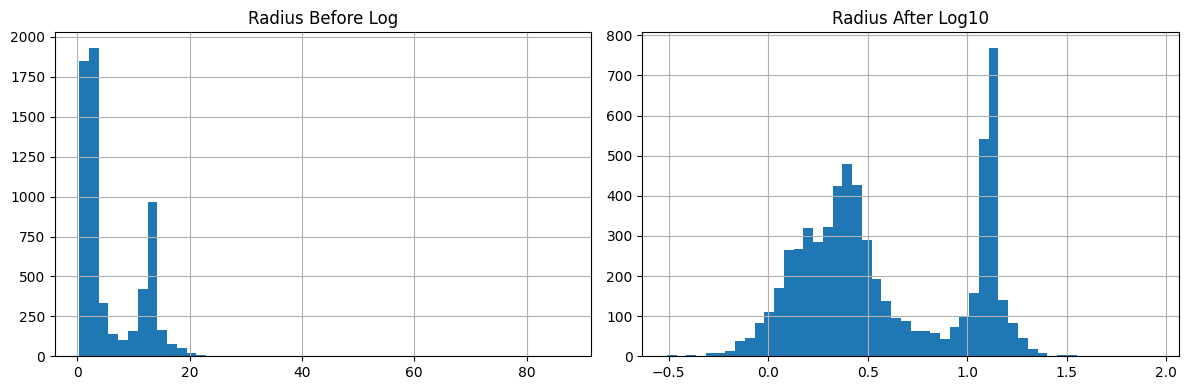

In [19]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

df["pl_rade"].hist(bins=50, ax=ax[0])
ax[0].set_title("Radius Before Log")

np.log10(df["pl_rade"]).hist(bins=50, ax=ax[1])
ax[1].set_title("Radius After Log10")

plt.tight_layout()
plt.show()

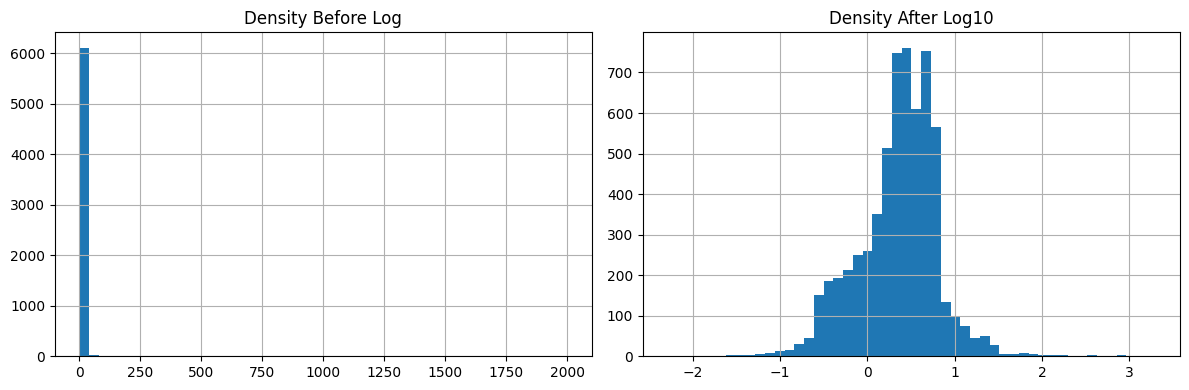

In [20]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

df["pl_dens"].hist(bins=50, ax=ax[0])
ax[0].set_title("Density Before Log")

np.log10(df["pl_dens"]).hist(bins=50, ax=ax[1])
ax[1].set_title("Density After Log10")

plt.tight_layout()
plt.show()

we understand that log transformation helps for all the featues. but before applying transformation we need to check for any negative values

In [21]:
for col in planet_features_core:
    print(col, df[col].min())

pl_rade 0.3098
pl_bmasse 0.02
pl_dens 0.0051
pl_orbsmax 0.0044


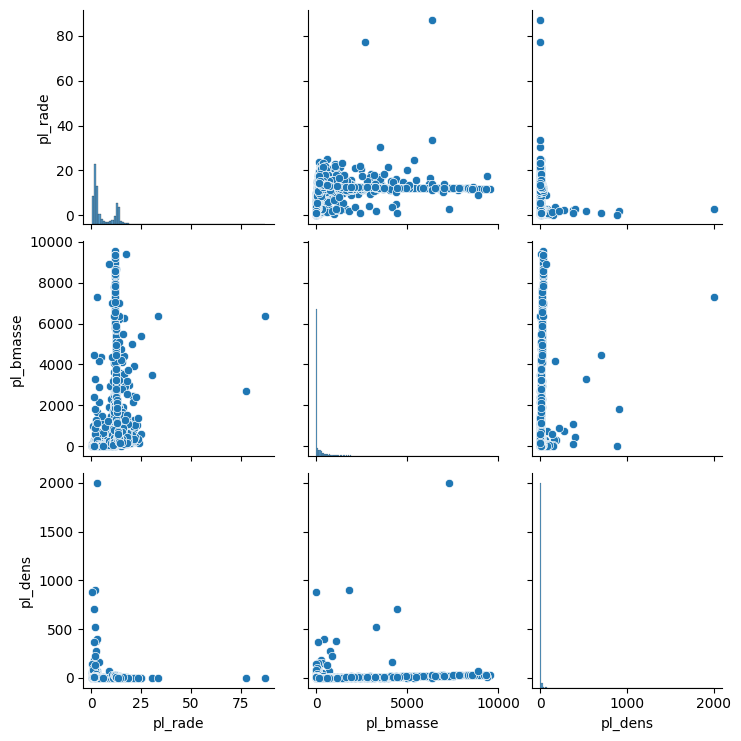

In [22]:
sns.pairplot(
    df[[
        "pl_rade",
        "pl_bmasse",
        "pl_dens"
    ]]
)

plt.show()

clearly Density is not acting like a duplicate feature

In [23]:
planet_features_core = [
    "pl_rade",
    "pl_bmasse",
    "pl_dens",
    "pl_orbsmax"
]

df[planet_features_core].describe()

,pl_rade,pl_bmasse,pl_dens,pl_orbsmax
count,6238.000000,6257.000000,6147.000000,5863.000000
mean,5.805911,399.578297,4.841406,15.652660
std,5.404937,1130.684394,34.166999,348.180059
min,0.309800,0.020000,0.005100,0.004400
25%,1.840000,4.270000,1.300000,0.052395
50%,2.840000,9.200000,2.530000,0.102330
75%,11.898182,184.022648,4.540000,0.305450
max,87.205870,9534.852210,2000.000000,19000.000000


### Feature Engineering Observation

All selected planetary features exhibit strong right-skewness and contain extreme outliers.

Mass, density and orbital distance span several orders of magnitude.

Log10 transformations significantly improve the visibility of planetary populations and reduce the influence of extreme values.

Therefore, log-transformed versions of these features will be evaluated for clustering.

In [24]:
df["log_pl_rade"] = np.log10(df["pl_rade"])
df["log_pl_bmasse"] = np.log10(df["pl_bmasse"])
df["log_pl_dens"] = np.log10(df["pl_dens"])
df["log_pl_orbsmax"] = np.log10(df["pl_orbsmax"])

/var/folders/zq/8j1g8nx571l4jtmw_t1d4njw0000gn/T/ipykernel_38136/662052500.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["log_pl_rade"] = np.log10(df["pl_rade"])
/var/folders/zq/8j1g8nx571l4jtmw_t1d4njw0000gn/T/ipykernel_38136/662052500.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["log_pl_bmasse"] = np.log10(df["pl_bmasse"])
/var/folders/zq/8j1g8nx571l4jtmw_t1d4njw0000gn/T/ipykernel_38136/662052500.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` m

In [25]:
log_features = [
    "log_pl_rade",
    "log_pl_bmasse",
    "log_pl_dens",
    "log_pl_orbsmax"
]

df[log_features].describe()

,log_pl_rade,log_pl_bmasse,log_pl_dens,log_pl_orbsmax
count,6238.000000,6257.000000,6147.000000,5863.000000
mean,0.578690,1.376220,0.351463,-0.781432
std,0.403611,1.049294,0.459365,0.753786
min,-0.508919,-1.698970,-2.292430,-2.356547
25%,0.264818,0.630428,0.113943,-1.280710
50%,0.453318,0.963788,0.403121,-0.989997
75%,1.075481,2.264871,0.657056,-0.515060
max,1.940546,3.979314,3.301030,4.278754


we are using k-means for clusting which means we need to try mean=0 and std=1

### feature selection

Raw NASA Data
      ↓
Feature Selection
      ↓
Log Transform
      ↓
Drop Missing Rows
      ↓
Feature Scaling   ← Next
      ↓
K-Means Clustering
      ↓
Optimal K Selection
      ↓
Cluster Interpretation

we need to create 2 datasets for now we do A dropping missing values

In [27]:
planet_drop = df[
    [
        "log_pl_rade",
        "log_pl_bmasse",
        "log_pl_dens",
        "log_pl_orbsmax"
    ]
].dropna()

planet_drop.shape

(5733, 4)